In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
listings = pd.read_csv('../data/listings.csv.gz', compression='gzip', low_memory=False)
calendar = pd.read_csv('../data/calendar.csv.gz', compression='gzip')
reviews = pd.read_csv('../data/reviews.csv')
listings_clean = pd.read_csv('../data/listings_clean.csv')

In [3]:
daily = (calendar
 .assign(available=lambda d: d['available'].map({'t': 1, 'f': 0}))
 .groupby('date')
 .agg(occupancy_rate=('available', lambda x: 1 - x.mean()))
 .reset_index())



In [5]:
daily.head()


,date,occupancy_rate
0,2026-06-23,0.784693
1,2026-06-24,0.653776
2,2026-06-25,0.759459
3,2026-06-26,0.741895
4,2026-06-27,0.722276


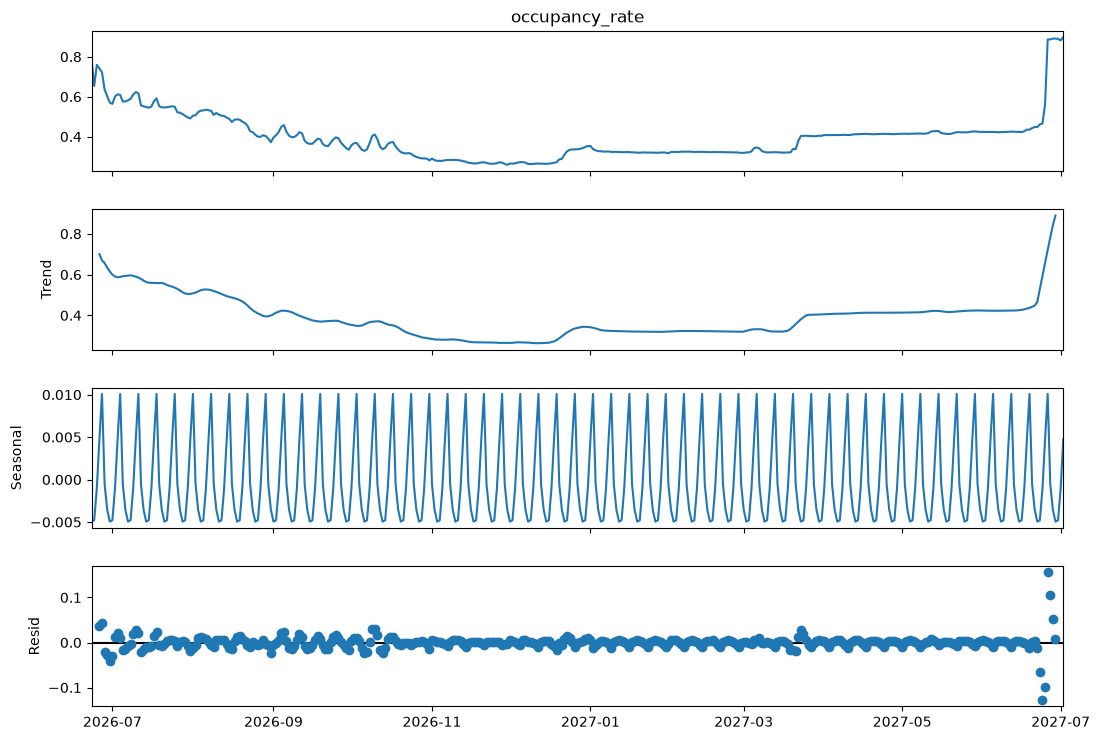

In [15]:
ts = daily.assign(date=lambda d: pd.to_datetime(d['date'])).set_index('date')['occupancy_rate'].asfreq('D').interpolate()
result = seasonal_decompose(ts, model='additive', period=7)
fig = result.plot()
fig.set_size_inches(12, 8)
plt.show()

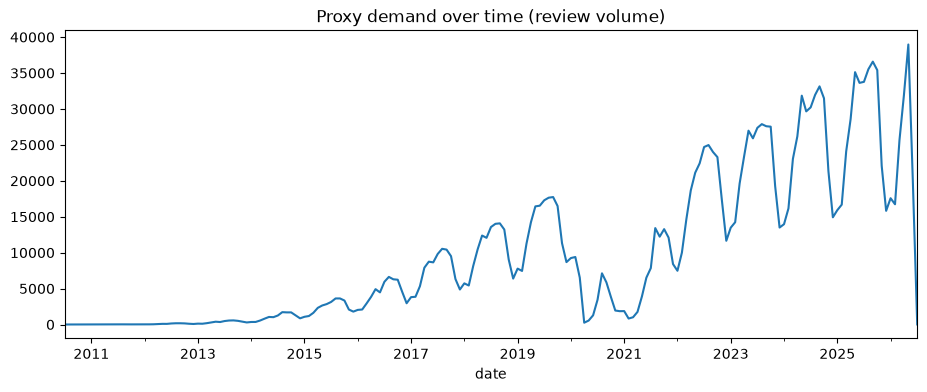

In [24]:
reviews['date'] = pd.to_datetime(reviews['date'])
monthly_reviews = (reviews
 .groupby(reviews['date'].dt.to_period('M'))
 .size()
 .rename('review_count'))
monthly_reviews.plot(figsize=(11, 4), title='Proxy demand over time (review volume)')
plt.show()
